# RAMMs V3

RAMMs V3 models a reconfigurable architected mechanical metamaterial (RAMM) using three core classes:

- **RAMM_Chain**
  - Contains **n** RAMM units.
  - Stores whether the chain geometry is **valid**.
  - Computes the chain's remaining **degrees of freedom (DoFs)** using a Maxwell–Calladine-inspired Jacobian analysis.

- **RAMM_Unit**
  - Contains four **RAMM_Nodes**.
  - Contains four **RAMM_Struts** (all equal length).
  - The entire unit geometry is determined from a single reference node and the unit's relative rotation.

- **RAMM_Node**
  - Stores the coordinates of a node.
  - Knows its descriptor (e.g., `0T`, `1L`) once assigned to a chain.

- **RAMM_Strut**
  - Connects two RAMM_Nodes.
  - Knows its descriptor (e.g., `0B0L`) and orientation.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
plt.style.use("seaborn-v0_8-whitegrid")
import plotly.graph_objects as go
import copy
import re
import pprint
import math
from enum import Enum
from plotly.subplots import make_subplots
from collections import Counter
from scipy.optimize import root
from IPython.display import display # for printing things in LaTex
from matplotlib.lines import Line2D
from dataclasses import dataclass

## Classes

### Custom Error Classes

In [2]:
class InvalidRAMMGeometryError(Exception):
    pass

### Custom RAMMs Classes

In [3]:
class UnitType(Enum):
    RAILED = "railed"
    FREE = "free"


class RAMM_Node:
    """
    NOTE: RAMM_Node should only be called when a RAMM_Unit is created (i.e inside the RAMM_Unit Class)
        which should only be called when a RAMM_Chain is created.
        This is because the node unit_index can only be assigned when a chain is created.
    """
    def __init__(self, long_name, coordinates):
        self.long_name = long_name
        # Coordinates are stored as (y, z):
        # y = horizontal position
        # z = vertical position
        self.coordinates = coordinates
        self.unit_index = None

    @property
    def get_details(self):
        return f"{self.long_name}: {self.coordinates}"

    @property
    def descriptor(self):
        """
        Return a shortened name/descriptor describing the node 
        (ex. the top node of unit 0 will the descriptor '0T'
        when the unit is assigned when RAMM_Node is called
        during creation in the RAMM_Unit class.
        """
        return f"{self.unit_index}{self.long_name[0].upper()}"

    def __str__(self):
        return self.descriptor
    

class RAMM_Strut:
    """
    Nodes should be passed in clockwise order (i.e node_2 should be located clockwise relative to node_1)
    """
    def __init__(self, node_1, node_2):
        self.node_1 = node_1
        self.node_2 = node_2

    @property
    def long_name(self):
        return f"{self.node_1.long_name} -> {self.node_2.long_name}"
    
    @property
    def descriptor(self) -> str:
        """
        Return a shortened name/descriptor describing the segment 
        (ex. segment bottom -> left on unit has the descriptor '1B1L'.
        """
        return (
            f"{self.node_1.descriptor}"
            f"{self.node_2.descriptor}"
    )

    def __str__(self):
        return self.descriptor


class RAMM_Unit:
    """
    Nodes should be passed in clockwise order (starting with the top node)
    """
    def __init__(
        self,
        top_node,
        right_node,
        bottom_node,
        left_node,
        unit_type # RAILED or FREE
    ):
        self.unit_type = unit_type

        self.top_node = top_node
        self.right_node = right_node
        self.bottom_node = bottom_node
        self.left_node = left_node

        self.nodes = [
            top_node,
            right_node,
            bottom_node,
            left_node
        ]

        # Validate geometry before creating struts
        self.validate_geometry()

        # Struts are directed clockwise around the unit, starting from the top
        # i.e. the first strut starts at the top node and ends at the right node
        self.struts = [
            RAMM_Strut(top_node, right_node),
            RAMM_Strut(right_node, bottom_node),
            RAMM_Strut(bottom_node, left_node),
            RAMM_Strut(left_node, top_node)
        ]

    # WARNING: validation method may need to change if physical geometry changes
    def validate_geometry(self):
        """
        Confirm that all four struts have equal length.
        """
        distances = []

        for i in range(4):
            node_1 = self.nodes[i] # the first node in the list should be the top node

            # Move to the next node in the diamond
            # Index 3 wraps back to index 0
            node_2 = self.nodes[(i + 1) % 4]

            y1, z1 = node_1.coordinates
            y2, z2 = node_2.coordinates

            distance = math.sqrt(
                (y2 - y1) ** 2 +
                (z2 - z1) ** 2
            )

            distances.append(distance)

        if not all(
            math.isclose(distance, distances[0])
            for distance in distances
        ):
            raise InvalidRAMMGeometryError(
                "RAMM unit struts must have equal length."
            )

    @classmethod
    def generate(
        cls,
        bottom_position,
        unit_type,
        rotation=0
    ):
        """
        Generate a RAMM unit.

        Parameters
        ----------
        bottom_position:
            Bottom-node position given as (y, z).

        unit_type:
            UnitType.FREE or UnitType.RAILED.

        rotation:
            Counterclockwise rotation in degrees about the bottom node.
        """

        bottom_y, bottom_z = bottom_position

        # Node positions relative to the bottom node.
        # Coordinates are (y, z).
        local_nodes = {
            "bottom": (0, 0),
            "right":  (8, 10),
            "top":    (0, 20),
            "left":   (-8, 10)
        }

        theta = math.radians(rotation)

        def transform(point):
            local_y, local_z = point

            # Rotate about the bottom node.
            rotated_y = (
                local_y * math.cos(theta)
                - local_z * math.sin(theta)
            )

            rotated_z = (
                local_y * math.sin(theta)
                + local_z * math.cos(theta)
            )

            # Translate to the requested bottom-node position.
            global_y = bottom_y + rotated_y
            global_z = bottom_z + rotated_z

            return global_y, global_z

        bottom_node = RAMM_Node(
            "bottom",
            transform(local_nodes["bottom"])
        )

        right_node = RAMM_Node(
            "right",
            transform(local_nodes["right"])
        )

        top_node = RAMM_Node(
            "top",
            transform(local_nodes["top"])
        )

        left_node = RAMM_Node(
            "left",
            transform(local_nodes["left"])
        )

        return cls(
            top_node=top_node,
            right_node=right_node,
            bottom_node=bottom_node,
            left_node=left_node,
            unit_type=unit_type
        )


class RAMM_Chain:
    def __init__(self):
        self.units = []

    def validate_chain_geometry_upon_creation(self):
        for i, unit in enumerate(self.units):

            # Unit 0 must always be railed.
            if i == 0 and unit.unit_type == UnitType.FREE:
                raise InvalidRAMMGeometryError(
                    "Unit 0 must be a railed unit."
                )

            # A free unit must initially have zero relative horizontal y-offset from the preceding unit 
            # (because IRL, it's bottom node is constrained by by the rails in RAILED unit preceding it)
            if unit.unit_type == UnitType.FREE:
                previous_unit = self.units[i - 1]

                free_y = unit.bottom_node.coordinates[0]
                neighbor_y = previous_unit.bottom_node.coordinates[0]

                if not math.isclose(free_y, neighbor_y):
                    raise InvalidRAMMGeometryError(
                        "A free unit must have zero relative y-offset from its neighboring railed unit "
                        "upon chain creation."
                    )
                
    def get_node_by_descriptor(self, node_descriptor):
        unit_index = int(node_descriptor[0])
        unit = self.units[unit_index]
        
        for node in unit.nodes:
            if node.descriptor == node_descriptor:
                return node

    def get_segment_by_descriptor(self, segment_descriptor):
        unit_index = int(segment_descriptor[0])
        unit = self.units[unit_index]

        for segment in unit.struts:
            if segment.descriptor == segment_descriptor:
                return segment

        raise ValueError(
            f"Unit {unit_index} has no segment "
            f"'{segment_descriptor}'."
        )

    def get_node_by_long_name(self, unit_index, node_long_name):
        unit = self.units[unit_index]

        for node in unit.nodes:
            if node.long_name == node_long_name:
                return node

        raise ValueError(
            f"Unit {unit_index} has no node labeled "
            f"'{node_long_name}'."
        )

    def get_segment_by_long_name(self, unit_index, segment_long_name):
        unit = self.units[unit_index]

        for segment in unit.struts:
            if segment.long_name == segment_long_name:
                return segment

        raise ValueError(
            f"Unit {unit_index} has no segment "
            f"'{segment_long_name}'."
        )

    @classmethod
    def generate(
        cls,
        n_units,
        start_position,
        offsets,
        rotations=None
    ):
        """
        Generate a RAMM chain.

        Unit types automatically alternate:

            Unit 0: RAILED
            Unit 1: FREE
            Unit 2: RAILED
            Unit 3: FREE
            ...

        Parameters
        ----------
        n_units:
            Desired number of units in the chain.

        start_position:
            Bottom-node position (y, z) of the first unit.

        offsets:
            May be provided as:

            - one offset tuple, such as (0, 10), which is repeated;
            - a sequence containing one offset, which is repeated;
            - a sequence containing two offsets, which are alternated;
            - a sequence containing exactly n_units - 1 offsets.

        rotations:
            May be provided as:

            - None, giving every unit a rotation of zero;
            - one numeric rotation, which is repeated;
            - a sequence containing one rotation, which is repeated;
            - a sequence containing two rotations, which are alternated;
            - a sequence containing exactly n_units rotations.

            Rotations are given in degrees.
        """

        if n_units < 1:
            raise ValueError(
                "A chain must contain at least one unit."
            )

        required_offset_count = n_units - 1

        # ---------------------------------------------------------
        # Expand offsets
        # ---------------------------------------------------------

        if required_offset_count == 0:
            expanded_offsets = []

        # A single offset passed directly, such as (0, 10).
        elif (
            isinstance(offsets, tuple)
            and len(offsets) == 2
            and all(
                isinstance(value, (int, float))
                for value in offsets
            )
        ):
            expanded_offsets = [
                offsets
                for _ in range(required_offset_count)
            ]

        elif isinstance(offsets, (list, tuple)):
            if len(offsets) == 0:
                raise ValueError(
                    "At least one offset must be provided "
                    "for a chain containing multiple units."
                )

            if len(offsets) == 1:
                expanded_offsets = [
                    offsets[0]
                    for _ in range(required_offset_count)
                ]

            elif len(offsets) == 2:
                expanded_offsets = [
                    offsets[i % 2]
                    for i in range(required_offset_count)
                ]

            elif len(offsets) == required_offset_count:
                expanded_offsets = list(offsets)

            else:
                raise ValueError(
                    "offsets must contain one offset, "
                    "two alternating offsets, or exactly "
                    f"{required_offset_count} offsets."
                )

        else:
            raise TypeError(
                "offsets must be an offset tuple or a sequence "
                "of offset tuples."
            )

        # Validate each expanded offset.
        for offset in expanded_offsets:
            if (
                not isinstance(offset, (list, tuple))
                or len(offset) != 2
                or not all(
                    isinstance(value, (int, float))
                    for value in offset
                )
            ):
                raise TypeError(
                    "Each offset must be a numeric "
                    "(delta_y, delta_z) pair."
                )

        # ---------------------------------------------------------
        # Expand rotations
        # ---------------------------------------------------------

        if rotations is None:
            expanded_rotations = [0] * n_units

        # One rotation passed directly, such as 15.
        elif isinstance(rotations, (int, float)):
            expanded_rotations = [
                rotations
                for _ in range(n_units)
            ]

        elif isinstance(rotations, (list, tuple)):
            if len(rotations) == 0:
                raise ValueError(
                    "rotations cannot be an empty sequence."
                )

            if not all(
                isinstance(rotation, (int, float))
                for rotation in rotations
            ):
                raise TypeError(
                    "Every rotation must be numeric."
                )

            if len(rotations) == 1:
                expanded_rotations = [
                    rotations[0]
                    for _ in range(n_units)
                ]

            elif len(rotations) == 2:
                expanded_rotations = [
                    rotations[i % 2]
                    for i in range(n_units)
                ]

            elif len(rotations) == n_units:
                expanded_rotations = list(rotations)

            else:
                raise ValueError(
                    "rotations must contain one rotation, "
                    "two alternating rotations, or exactly "
                    f"{n_units} rotations."
                )

        else:
            raise TypeError(
                "rotations must be numeric, a sequence of "
                "numeric rotations, or None."
            )

        # ---------------------------------------------------------
        # Construct the chain
        # ---------------------------------------------------------

        chain = cls()
        current_position = start_position

        for i in range(n_units):
            unit_type = (
                UnitType.RAILED
                if i % 2 == 0
                else UnitType.FREE
            )

            unit = RAMM_Unit.generate(
                bottom_position=current_position,
                unit_type=unit_type,
                rotation=expanded_rotations[i]
            )

            chain.units.append(unit)

            # Move to the bottom-node position of the next unit.
            if i < required_offset_count:
                delta_y, delta_z = expanded_offsets[i]
                current_y, current_z = current_position

                current_position = (
                    current_y + delta_y,
                    current_z + delta_z
                )

        # Assign each node to its unit after all units are created.
        for i, unit in enumerate(chain.units):
            for node in unit.nodes:
                node.unit_index = i

        chain.validate_chain_geometry_upon_creation()

        return chain

two_unit_chain = RAMM_Chain.generate(
    n_units=2,
    start_position=(0, 0),
    offsets=(0, 10)
)

four_unit_chain = RAMM_Chain.generate(
    n_units=4,
    start_position=(0, 0),
    offsets=[
        (0, 10),
        (0, 14),
        (0, 10)
    ],
)

#### Test Chain Creation Classes

In [4]:
print("Four Unit Chain:")
for i, unit in enumerate(four_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.long_name}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut.long_name}")

print("\n")

print("Two Unit Chain:")
for i, unit in enumerate(two_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.long_name}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut.long_name}")

Four Unit Chain:
Unit 0: railed
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 1: free
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 2: railed
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 3: free
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top


Two Unit Chain:
Unit 0: railed
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top
Unit 1: free
Nodes:
  top
  right
  bottom
  left
Struts:
  top -> right
  right -> bottom
  bottom -> left
  left -> top


In [5]:
print("Four Unit Chain:")
for i, unit in enumerate(four_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.descriptor}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut}")

print("\n")

print("Two Unit Chain:")
for i, unit in enumerate(two_unit_chain.units):
    print(f"Unit {i}: {unit.unit_type.value}")

    print("Nodes:")
    for node in unit.nodes:
        print(f"  {node.descriptor}")

    print("Struts:")
    for strut in unit.struts:
        print(f"  {strut}")

Four Unit Chain:
Unit 0: railed
Nodes:
  0T
  0R
  0B
  0L
Struts:
  0T0R
  0R0B
  0B0L
  0L0T
Unit 1: free
Nodes:
  1T
  1R
  1B
  1L
Struts:
  1T1R
  1R1B
  1B1L
  1L1T
Unit 2: railed
Nodes:
  2T
  2R
  2B
  2L
Struts:
  2T2R
  2R2B
  2B2L
  2L2T
Unit 3: free
Nodes:
  3T
  3R
  3B
  3L
Struts:
  3T3R
  3R3B
  3B3L
  3L3T


Two Unit Chain:
Unit 0: railed
Nodes:
  0T
  0R
  0B
  0L
Struts:
  0T0R
  0R0B
  0B0L
  0L0T
Unit 1: free
Nodes:
  1T
  1R
  1B
  1L
Struts:
  1T1R
  1R1B
  1B1L
  1L1T


## Visualization Methods

In [6]:
def plot_geometry(chain, ax=None, show=True, plot_title=None):
    """
    Plot a RAMM chain.

    Coordinates are interpreted as:
        y = horizontal axis
        z = vertical axis
    """

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 10))

    for unit_index, unit in enumerate(chain.units):

        # Change strut color based on unit type
        if unit.unit_type == UnitType.RAILED:
            unit_color = "#1f3f6d"
        else:
            unit_color = "#6699cc"

        # Plot each strut
        for strut in unit.struts:
            node_1_y, node_1_z = strut.node_1.coordinates
            node_2_y, node_2_z = strut.node_2.coordinates

            ax.plot(
                [node_1_y, node_2_y],
                [node_1_z, node_2_z],
                color=unit_color,
                linewidth=5,
                solid_capstyle="round",
                zorder=1,
            )

        # Plot and label each node
        for node in unit.nodes:
            y, z = node.coordinates

            ax.scatter(
                y,
                z,
                s=300,
                facecolor="lightgray",
                edgecolor="lightgray",
                linewidth=4,
                zorder=2,
            )

            ax.annotate(
                f"{node.descriptor}",
                xy=(y, z),
                ha="center",
                va="center",
                fontsize=11,
                color=unit_color,
                zorder=3,
            )
    if plot_title == None:
        ax.set_title("RAMMs Configuration Geometry")
    else:
        ax.set_title(plot_title)
    ax.set_xlabel("y")
    ax.set_ylabel("z")

    # Preserve the actual geometry proportions.
    ax.set_aspect("equal", adjustable="box")

    # Add a small amount of space around the geometry.
    ax.margins(x=0.1, y=0.1)

    if show:
        plt.show()

    return ax

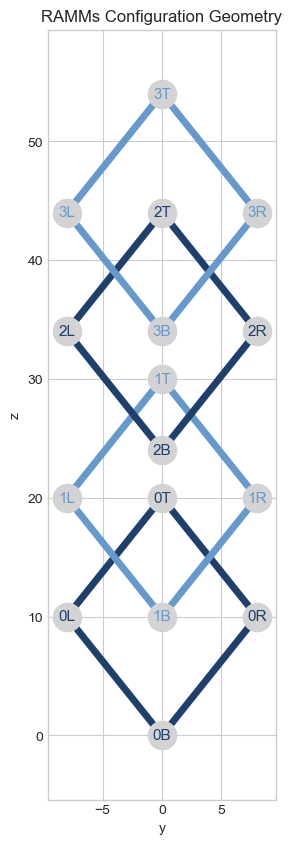

<Axes: title={'center': 'RAMMs Configuration Geometry'}, xlabel='y', ylabel='z'>

In [7]:
plot_geometry(four_unit_chain)

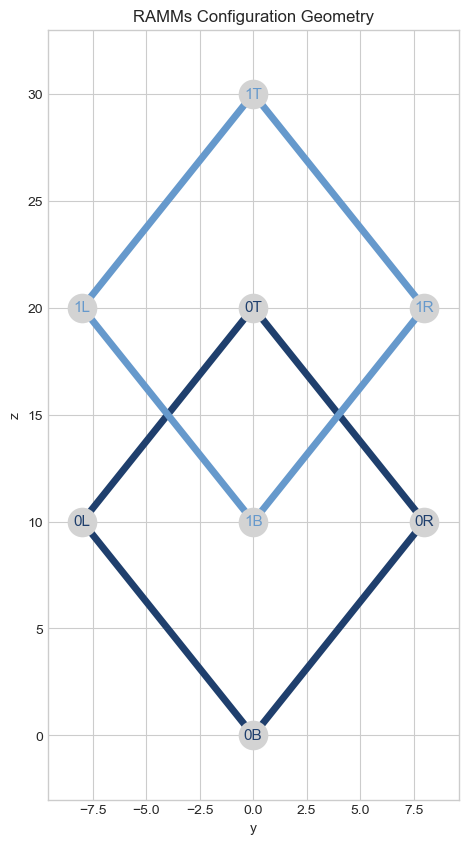

<Axes: title={'center': 'RAMMs Configuration Geometry'}, xlabel='y', ylabel='z'>

In [8]:
plot_geometry(two_unit_chain)

## Gap Distance Methods

### Gap Classes

In [9]:
@dataclass
class GapResult:
    length_mm: float
    projection_coordinate: tuple[float, float]
    node_coordinate: tuple[float, float]

class Gap:
    def __init__(
        self,
        name,
        segment_1,
        node,
        orientation,
        result,
        segment_2=None
    ):
        self.name = name
        self.segment_1 = segment_1
        self.segment_2 = segment_2
        self.node = node
        self.orientation = orientation
        self.result = result

    @property
    def length_mm(self):
        return self.result.length_mm

### Gap Plotting Functions

In [10]:
def plot_gap(chain, gap):
    """
    Plot a RAMM chain and overlay a calculated gap in red.
    """

    plot_title=f"Gap Between Segment {gap.segment_1} and Node {gap.node}"

    _, ax = plt.subplots(figsize=(7, 10))

    # Plot the chain without showing it yet.
    plot_geometry(
        chain=chain,
        ax=ax,
        show=False,
        plot_title=plot_title,
    )

    qy, qz = gap.result.projection_coordinate
    py, pz = gap.result.node_coordinate

    # Draw the gap from closest point Q to node P.
    ax.plot(
        [qy, py],
        [qz, pz],
        color="red",
        linestyle="--",
        linewidth=3,
        zorder=10,
        label=f"g = {gap.length_mm:.3f}",
    )

    # Mark closest point Q.
    ax.scatter(
        qy,
        qz,
        color="red",
        marker="x",
        s=100,
        linewidths=3,
        zorder=11,
    )

    ax.annotate(
        "Q",
        xy=(qy, qz),
        xytext=(6, 6),
        textcoords="offset points",
        color="red",
        fontsize=11,
        zorder=12,
    )

    midpoint_y = (qy + py) / 2
    midpoint_z = (qz + pz) / 2

    ax.annotate(
        f"g = {gap.length_mm:.3f}",
        xy=(midpoint_y, midpoint_z),
        xytext=(6, 6),
        textcoords="offset points",
        color="red",
        fontsize=11,
        zorder=12,
    )

    ax.legend()

    plt.show()

### Segment-Node Distance Functions

#### Main Functions

In [11]:
def get_node_segment_distance(node, segment, orientation):
    """
    Calculate the signed gap between a node and a finite segment.

    Coordinates are interpreted as:
        y = horizontal
        z = vertical

    Parameters
    ----------
    segment : RAMM_Strut
        Directed from segment.left_node (A) to segment.right_node (B).

    node : RAMM_Node
        Node P whose distance from the segment is calculated.

    orientation : str
        Expected location of P relative to directed segment A -> B.

        Accepted values:
            "counterclockwise"
            "clockwise"

    Returns
    -------
    GapResult
        Contains:
            value
            projection_point as (y, z)
            node_point as (y, z)
    """

    ay, az = segment.node_1.coordinates
    by, bz = segment.node_2.coordinates
    py, pz = node.coordinates

    # u = B - A
    uy = by - ay
    uz = bz - az

    # v = P - A
    vy = py - ay
    vz = pz - az

    u_length_squared = uy**2 + uz**2

    if math.isclose(u_length_squared, 0.0):
        raise InvalidRAMMGeometryError(
            "Cannot calculate a gap from a zero-length segment."
        )

    # Projection parameter on the infinite line:
    # t = (v · u) / ||u||²
    t = (vy * uy + vz * uz) / u_length_squared

    # Restrict the closest point to the finite segment.
    t = max(0.0, min(1.0, t))

    # Q = A + t*u
    qy = ay + t * uy
    qz = az + t * uz

    # Unsigned gap: g = ||P - Q||
    unsigned_gap = math.hypot(
        py - qy,
        pz - qz
    )

    # 2D cross product u × v.
    #
    # Even though the coordinate names are y and z, this is still
    # the standard signed area calculation in the plotted y-z plane.
    cross_product = uy * vz - uz * vy

    orientation = orientation.lower()

    if orientation == "counterclockwise":
        expected_side = 1
    elif orientation == "clockwise":
        expected_side = -1
    else:
        raise ValueError(
            "orientation must be 'clockwise' or 'counterclockwise'"
        )

    if math.isclose(cross_product, 0.0, abs_tol=1e-12):
        signed_gap = 0.0
    else:
        actual_side = 1 if cross_product > 0 else -1

        signed_gap = (
            unsigned_gap
            if actual_side == expected_side
            else -unsigned_gap
        )

    return GapResult(
        length_mm=signed_gap,
        projection_coordinate=(qy, qz),
        node_coordinate=(py, pz),
    )


def get_node_segment_gap(node, segment, orientation, verbose=False):

    gap_result = get_node_segment_distance(
        node=node,
        segment=segment,
        orientation=orientation,
    )

    gap_name = (
        f"gap_{segment.descriptor}_"
        f"{node.descriptor}"
    )

    gap = Gap(
        name=gap_name,
        segment_1=segment,
        node=node,
        orientation=orientation,
        result=gap_result,
    )

    if verbose:
        if gap.length_mm < 0:
            print(
                f"Invalid configuration\n"
                f"Gap: {gap.length_mm:.6f} mm"
            )

        elif math.isclose(
            gap.length_mm,
            0.0,
            abs_tol=1e-6
        ):
            print("Contact")

        else:
            print(
                f"Segment {segment.descriptor} and "
                f"node {node.descriptor} "
                f"are not in contact.\n"
                f"Gap: {gap.length_mm:.6f} mm"
            )

    return gap

#### Testing Node-Segment Distance Method

In [12]:
RAMMs_unit_1 = 1
# NOTE: [Correct] Orientation is measured from the directed segment A→B toward the node
    # ex. the correct orientation of 1T1R (A = 1T, B = 1R) and node 0T is "clockwise":
        # rotate the segment 1T1R clockwise to get to node 0T
        # segments point from A -> B, and rotate about A

# Top unit segments
segment_1B1L = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "bottom -> left")
segment_1T1R = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "top -> right")
segment_1R1B = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "right -> bottom")
segment_1L1T = two_unit_chain.get_segment_by_long_name(RAMMs_unit_1, "left -> top")

# Unit 0 top node
node_0T = two_unit_chain.units[0].top_node
node_0R = two_unit_chain.units[0].right_node
node_0B = two_unit_chain.units[0].bottom_node
node_0L = two_unit_chain.units[0].left_node

# Evaluate Bottom Unit Top Node and Top Unit Segment Gaps
gap_segment_1B1L_0T = get_node_segment_gap(node_0T, segment_1B1L, "clockwise", verbose=True)
gap_segment_1T1R_0T = get_node_segment_gap(node_0T, segment_1R1B, "clockwise", verbose=True)
gap_segment_1R1B_0T = get_node_segment_gap(node_0T, segment_1B1L, "clockwise", verbose=True)
gap_segment_1L1T_0T = get_node_segment_gap(node_0T, segment_1T1R, "clockwise", verbose=True)

# Evaluate Bottom Unit Bottom Node and Top Unit Segment Gaps
gap_segment_1B1L_0B = get_node_segment_gap(node_0B, segment_1B1L, "counterclockwise", verbose=True)
gap_segment_1R1B_0B = get_node_segment_gap(node_0B, segment_1R1B, "counterclockwise", verbose=True)

# Evaluate bottom unit left and right Nodes compared to respective left and right top unit segments
gap_segment_1B1L_0L = get_node_segment_gap(node_0L, segment_1B1L, "counterclockwise", verbose=True)
gap_segment_1R1B_0R = get_node_segment_gap(node_0R, segment_1R1B, "counterclockwise", verbose=True)

Segment 1B1L and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1R1B and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1B1L and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1T1R and node 0T are not in contact.
Gap: 6.246950 mm
Segment 1B1L and node 0B are not in contact.
Gap: 10.000000 mm
Segment 1R1B and node 0B are not in contact.
Gap: 10.000000 mm
Segment 1B1L and node 0L are not in contact.
Gap: 6.246950 mm
Segment 1R1B and node 0R are not in contact.
Gap: 6.246950 mm


##### Plot chain with gap overlay for each measurement

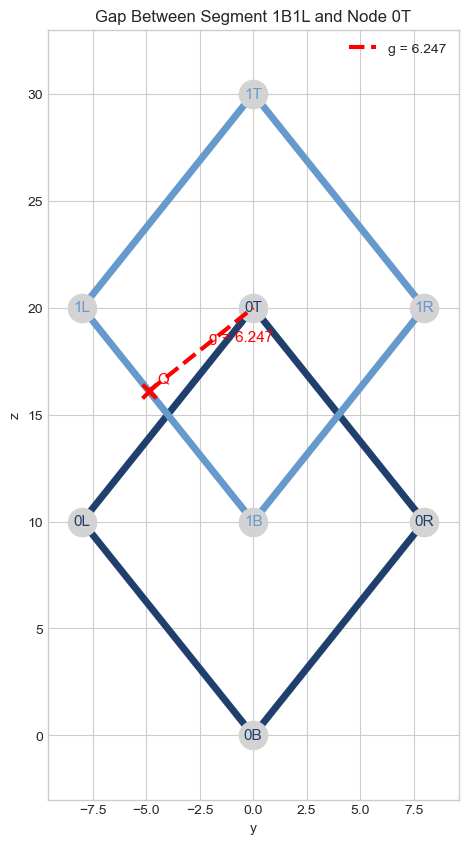

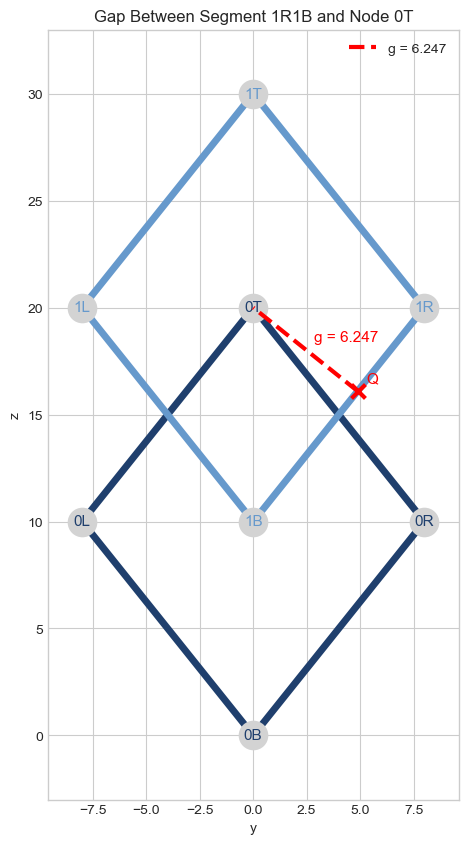

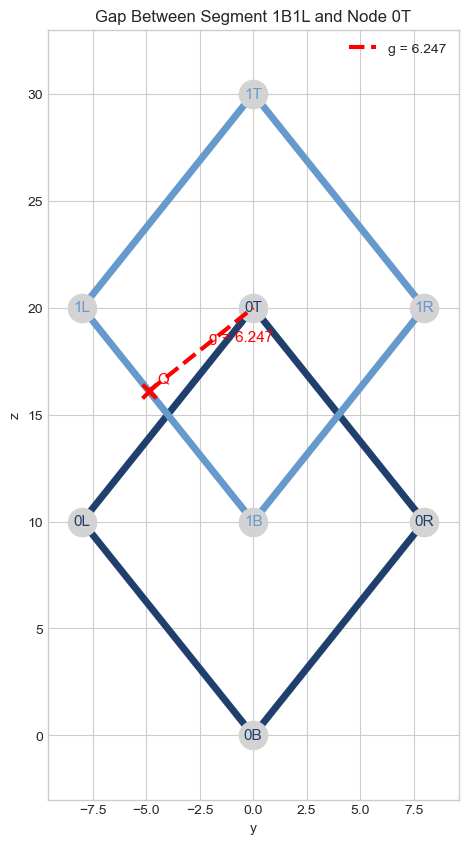

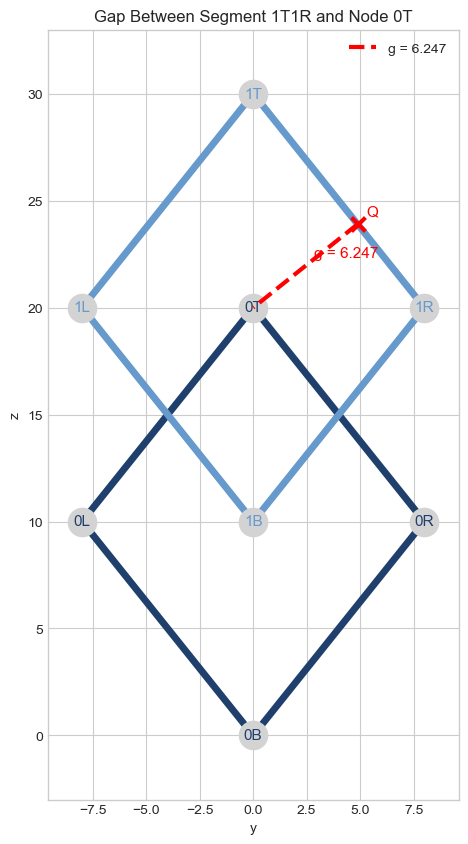

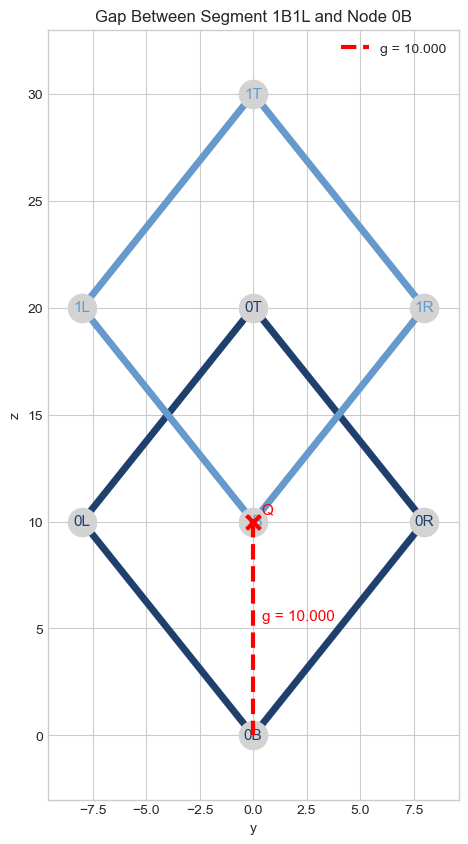

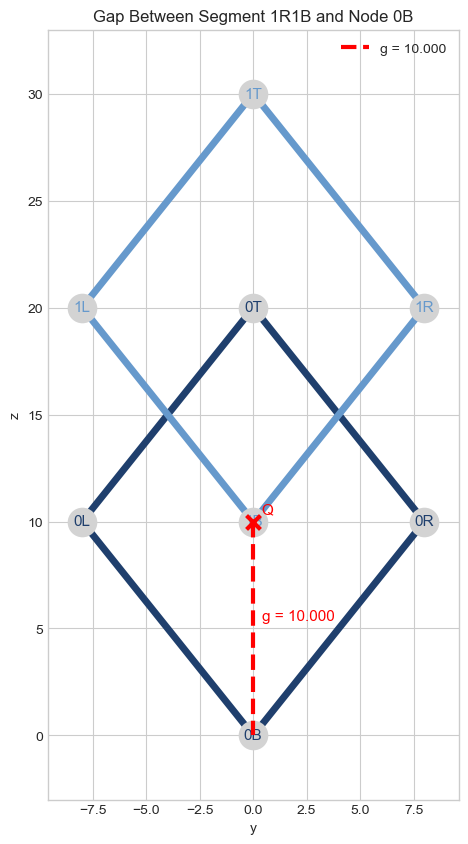

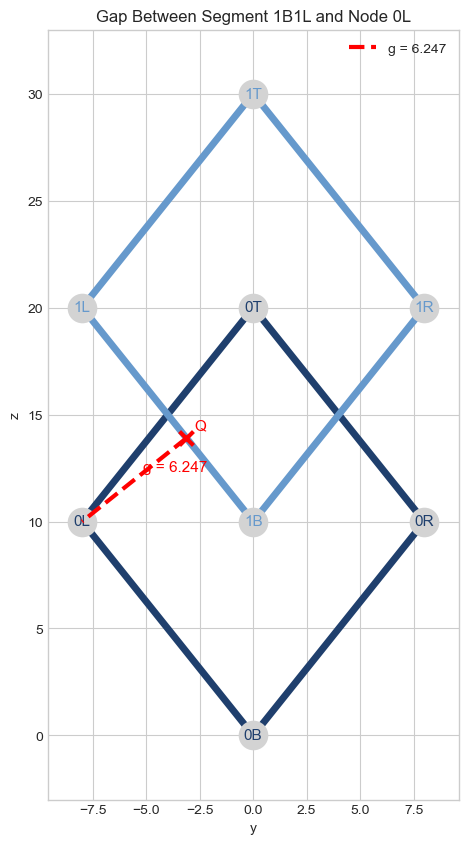

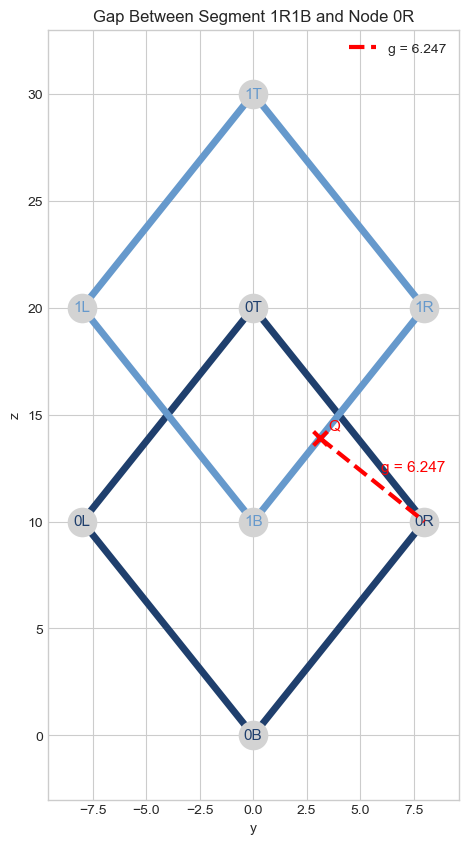

In [13]:
plot_gap(two_unit_chain, gap_segment_1B1L_0T)
plot_gap(two_unit_chain, gap_segment_1T1R_0T)
plot_gap(two_unit_chain, gap_segment_1R1B_0T)
plot_gap(two_unit_chain, gap_segment_1L1T_0T)
plot_gap(two_unit_chain, gap_segment_1B1L_0B)
plot_gap(two_unit_chain, gap_segment_1R1B_0B)
plot_gap(two_unit_chain, gap_segment_1B1L_0L)
plot_gap(two_unit_chain, gap_segment_1R1B_0R)

### Segment-Segment Distance Functions

### Symbolic Gaps

#### Symbolic Gap Classes and Functions

In [14]:
@dataclass
class SymbolicGap:
    A: sp.Matrix
    B: sp.Matrix
    P: sp.Matrix
    u: sp.Matrix
    v: sp.Matrix
    t: sp.Expr
    Q: sp.Matrix
    gap_vector: sp.Matrix
    gap_magnitude: sp.Expr

#### General Symbolic Gap Function

In [15]:
def get_symbolic_gap_general():

    Ay, Az = sp.symbols("Ay Az", real=True)
    By, Bz = sp.symbols("By Bz", real=True)
    Py, Pz = sp.symbols("Py Pz", real=True)

    A = sp.Matrix([Ay, Az])
    B = sp.Matrix([By, Bz])
    P = sp.Matrix([Py, Pz])

    u = B - A
    v = P - A

    u_squared_length = u.dot(u)
    t = v.dot(u) / u_squared_length

    Q = A + t * u
    gap_vector = P - Q
    gap_magnitude = gap_vector.norm()

    symbolic_gap = SymbolicGap(
        A=A,
        B=B,
        P=P,
        u=u,
        v=v,
        t=t,
        Q=Q,
        gap_vector=gap_vector,
        gap_magnitude=gap_magnitude,
    )

    return symbolic_gap

In [16]:
symbolic_gap = get_symbolic_gap_general()
print("Symbolic gap A:")
display(symbolic_gap.A)

print("Symbolic gap t:")
display(symbolic_gap.t)

print("Symbolic gap vector:")
display(symbolic_gap.gap_vector)

print("Symbolic gap magnitude:")
display(symbolic_gap.gap_magnitude)

Symbolic gap A:


Matrix([
[Ay],
[Az]])

Symbolic gap t:


((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2)

Symbolic gap vector:


Matrix([
[-Ay + Py - (-Ay + By)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2)],
[-Az + Pz - (-Az + Bz)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2)]])

Symbolic gap magnitude:


sqrt(Abs(-Ay + Py - (-Ay + By)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2))**2 + Abs(-Az + Pz - (-Az + Bz)*((-Ay + By)*(-Ay + Py) + (-Az + Bz)*(-Az + Pz))/((-Ay + By)**2 + (-Az + Bz)**2))**2)

#### Specific Symbolic Gap Function for a Node-Segment Gaps

In [17]:
def get_node_segment_symbolic_gap(node, segment):

    left_y, left_z = sp.symbols(
        f"A_{segment.node_1}_y "
        f"A_{segment.node_1}_z",
        real=True
    )

    right_y, right_z = sp.symbols(
        f"B_{segment.node_2}_y "
        f"B_{segment.node_2}_z",
        real=True
    )

    node_y, node_z = sp.symbols(
        f"P_{node}_y "
        f"P_{node}_z",
        real=True
    )

    A = sp.Matrix([left_y, left_z])
    B = sp.Matrix([right_y, right_z])
    P = sp.Matrix([node_y, node_z])

    u = B - A
    v = P - A

    u_squared_length = u.dot(u)
    t = v.dot(u) / u_squared_length

    Q = A + t * u
    gap_vector = P - Q
    gap_magnitude = gap_vector.norm()

    return SymbolicGap(
        A=A,
        B=B,
        P=P,
        u=u,
        v=v,
        t=t,
        Q=Q,
        gap_vector=gap_vector,
        gap_magnitude=gap_magnitude,
    )

In [18]:
symbolic_gap_1B1L_0T = get_node_segment_symbolic_gap(node_0T, segment_1B1L)
display(symbolic_gap_1B1L_0T.gap_magnitude)

sqrt(Abs(-A_1B_y + P_0T_y - (-A_1B_y + B_1L_y)*((-A_1B_y + B_1L_y)*(-A_1B_y + P_0T_y) + (-A_1B_z + B_1L_z)*(-A_1B_z + P_0T_z))/((-A_1B_y + B_1L_y)**2 + (-A_1B_z + B_1L_z)**2))**2 + Abs(-A_1B_z + P_0T_z - (-A_1B_z + B_1L_z)*((-A_1B_y + B_1L_y)*(-A_1B_y + P_0T_y) + (-A_1B_z + B_1L_z)*(-A_1B_z + P_0T_z))/((-A_1B_y + B_1L_y)**2 + (-A_1B_z + B_1L_z)**2))**2)

In [19]:
# DONT USE FOR JACOBIAN (USE FIRST ONE if we eval and node is on the correct side of gap)
def get_symbolic_gap_finite_segment(segment, node):

    # Create symbolic node positions.
    left_y, left_z = sp.symbols(
        f"A_{segment.node_1}_y "
        f"A_{segment.node_1}_z",
        real=True
    )

    right_y, right_z = sp.symbols(
        f"B_{segment.node_2}_y "
        f"B_{segment.node_2}_z",
        real=True
    )

    node_y, node_z = sp.symbols(
        f"P_{node}_y "
        f"P_{node}_z",
        real=True
    )

    A = sp.Matrix([left_y, left_z])
    B = sp.Matrix([right_y, right_z])
    P = sp.Matrix([node_y, node_z])

    u = B - A
    v = P - A

    u_squared_length = u.dot(u)

    if sp.simplify(u_squared_length) == 0:
        raise ValueError(
            "Cannot define a gap from a zero-length segment."
        )

    t = v.dot(u) / u_squared_length

    # Projection onto the infinite line.
    Q_line = A + t * u

    line_gap_vector = P - Q_line
    left_gap_vector = P - A
    right_gap_vector = P - B

    line_distance = line_gap_vector.norm()
    left_distance = left_gap_vector.norm()
    right_distance = right_gap_vector.norm()

    # Closest point on the finite segment.
    Q = sp.Piecewise(
        (A, t < 0),
        (B, t > 1),
        (Q_line, True)
    )

    gap_vector = sp.Piecewise(
        (left_gap_vector, t < 0),
        (right_gap_vector, t > 1),
        (line_gap_vector, True)
    )

    gap_magnitude = sp.Piecewise(
        (left_distance, t < 0),
        (right_distance, t > 1),
        (line_distance, True)
    )

    return SymbolicGap(
        A=A,
        B=B,
        P=P,
        u=u,
        v=v,
        t=t,
        Q=Q,
        gap_vector=gap_vector,
        gap_magnitude=gap_magnitude,
    )

#### Get Active Node-Segment Gaps for a Chain in a Specific Config

In [20]:
def get_candidate_gaps(chain):
    gaps = []

    for lower_unit in range(0, len(chain.units) - 1, 2):
        upper_unit = lower_unit + 1

        segment_BL = chain.get_segment_by_descriptor(
            f"{upper_unit}B{upper_unit}L"
        )
        segment_TR = chain.get_segment_by_descriptor(
            f"{upper_unit}T{upper_unit}R"
        )
        segment_RB = chain.get_segment_by_descriptor(
            f"{upper_unit}R{upper_unit}B"
        )
        segment_LT = chain.get_segment_by_descriptor(
            f"{upper_unit}L{upper_unit}T"
        )

        node_T = chain.get_node_by_descriptor(f"{lower_unit}T")
        node_R = chain.get_node_by_descriptor(f"{lower_unit}R")
        node_B = chain.get_node_by_descriptor(f"{lower_unit}B")
        node_L = chain.get_node_by_descriptor(f"{lower_unit}L")

        gaps.extend([
            get_node_segment_gap(node_T, segment_BL, "clockwise"),
            get_node_segment_gap(node_T, segment_TR, "clockwise"),
            get_node_segment_gap(node_T, segment_RB, "clockwise"),
            get_node_segment_gap(node_T, segment_LT, "clockwise"),

            get_node_segment_gap(node_B, segment_BL, "counterclockwise"),
            get_node_segment_gap(node_B, segment_RB, "counterclockwise"),

            get_node_segment_gap(node_L, segment_BL, "counterclockwise"),
            get_node_segment_gap(node_R, segment_RB, "counterclockwise"),
        ])

    return gaps

def get_active_gap_vector(candidate_gaps, tolerance=1e-6, verbose=False):
    active_gap_expressions = []

    for candidate in candidate_gaps:
        gap_length_mm = candidate.result.length_mm

        if verbose:
            if gap_length_mm < -tolerance:
                raise InvalidRAMMGeometryError(
                    f"{candidate.gap_name} has an invalid negative gap: {gap_length_mm}"
                )
            else:
                print(f"Gap between {candidate.segment_1} and {candidate.node} is greater than 0. \n Gap: {gap_length_mm}")

        if math.isclose(gap_length_mm, 0.0, abs_tol=tolerance):
            symbolic_gap = get_node_segment_symbolic_gap(
                candidate.node,
                candidate.segment
            )

            active_gap_expressions.append(symbolic_gap)

    return sp.Matrix(active_gap_expressions)

In [21]:
candidate_gaps = get_candidate_gaps(two_unit_chain)
get_active_gap_vector(candidate_gaps, verbose=True)

Gap between 1B1L and 0T is greater than 0. 
 Gap: 6.246950475544242
Gap between 1T1R and 0T is greater than 0. 
 Gap: 6.246950475544242
Gap between 1R1B and 0T is greater than 0. 
 Gap: 6.246950475544242
Gap between 1L1T and 0T is greater than 0. 
 Gap: 6.246950475544242
Gap between 1B1L and 0B is greater than 0. 
 Gap: 10.0
Gap between 1R1B and 0B is greater than 0. 
 Gap: 10.0
Gap between 1B1L and 0L is greater than 0. 
 Gap: 6.246950475544242
Gap between 1R1B and 0R is greater than 0. 
 Gap: 6.246950475544242


Matrix(0, 0, [])

## Find Max Angle (Contact Points) Functions

> <span style="color:red"><strong>⚠ TODO</strong></span>  
> Find the maximum allowable rotation (contact points) so we can test `get_active_gap_vector()` on a chain that should be in contact.

Then move on to the Jacobian.

### Find Max Angle for Two-Unit Chain
Rotate and translate top RAMM unit (use method in RAMM_Unit class)

### Find Max Angle for Three-Unit Chain

In [22]:
# TODO: Add a method to translate and/or rotate a free RAMM unit about its bottom node,
# then propagate the resulting rigid-body motion to all downstream units in the chain.

In [23]:
# TODO: write a method that takes a chain and analyzes the validity of the chain